# Oefentoets Computational Modelling
Deze oefentoets bestaat uit twee opdrachten met verschillende opgaven per opdracht. In de eerste opdracht gaan jullie aan de slag met het verkennen van een dataset en in de tweede opdracht met unsupervised learning. Voor deze oefentoets hebben jullie 60 minuten de tijd.

Lees de instructies hieronder goed door.

### Beantwoorden vragen
Licht jouw uitwerking toe. Documenteer belangrijke stukken code en licht jouw werkwijze toe. 

#### Code documenteren
Simpele code zoals het aanmaken van een leeg array of een train_test_split functie aanroepen hoeft niet toegelicht te worden, maar wanneer je iets doet dat belangrijk is om te begrijpen omdat het essentieel is voor de opdracht moet toegelicht worden. Leg dit uit m.b.v. commentaar bij de code.

#### Werkwijze toelichten
Om tot een oplossing te komen, voer je vaak meerdere stappen uit. Leg uit welke stappen je uitvoert, waarom deze stappen nodig zijn, de volgorde, etc. Gebruik hier voor een aparte 'Markdown' cel.

## Opdracht 1
In deze opdracht gaan jullie een dataset verkennen. We gebruiken hiervoor de IMDB movieset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df = pd.read_csv('movie.csv')
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


**Opgave 1.1.**

Bepaal of de kolommen `['duration','gross','budget','imdb_score']` outliers bevatten. Zo ja, zijn het zwakke of sterke outliers?

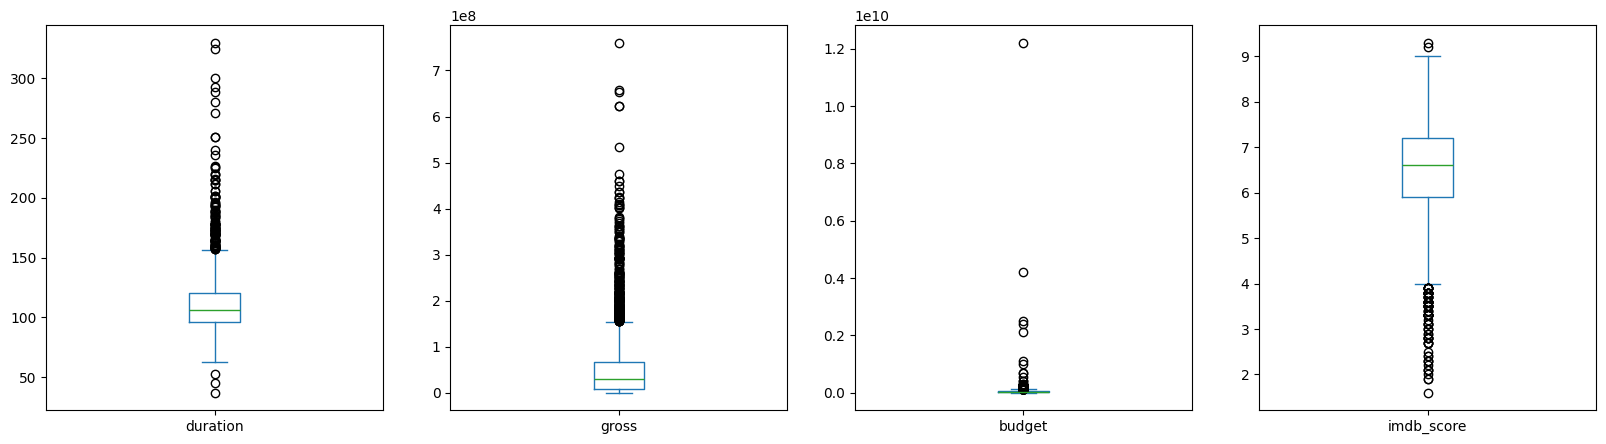

In [51]:
df[['duration', 'gross', 'budget', 'imdb_score']].plot(
    kind='box', 
    subplots=True, 
    layout=(1, 4),  # 1 row and 4 columns
    figsize=(20, 5),  # Adjust the width and height of the plot
    grid=False
)

plt.show()

In [32]:
df = df.dropna()

In [33]:
df.isna().sum()

color                        0
director_name                0
num_critic_for_reviews       0
duration                     0
director_facebook_likes      0
actor_3_facebook_likes       0
actor_2_name                 0
actor_1_facebook_likes       0
gross                        0
genres                       0
actor_1_name                 0
movie_title                  0
num_voted_users              0
cast_total_facebook_likes    0
actor_3_name                 0
facenumber_in_poster         0
plot_keywords                0
movie_imdb_link              0
num_user_for_reviews         0
language                     0
country                      0
content_rating               0
budget                       0
title_year                   0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64

In [34]:
df1 = df[['duration','gross','budget','imdb_score']].copy()

In [35]:
z_scores = np.abs((df1 - df1.mean()) / df1.std())
print(z_scores)

      duration      gross    budget  imdb_score
0     2.990809  10.066192  0.843888    1.359321
1     2.593446   3.651435  1.122601    0.601648
2     1.666266   2.096741  0.879280    0.317521
3     2.372689   5.624153  0.901400    1.927575
5     0.959843   0.290555  0.962009    0.128103
...        ...        ...       ...         ...
5026  0.011488   0.746420  0.204582    0.412230
5027  0.894516   0.738773  0.204558    0.980485
5033  1.468484   0.742314  0.204571    0.506939
5035  1.291879   0.719332  0.204571    0.412230
5042  0.894516   0.747142  0.204597    0.128103

[3755 rows x 4 columns]


In [37]:
threshold = 3
outliers = (z_scores > threshold)

# Display outliers (True indicates an outlier)
print(len(outliers))

3755


In [46]:
len(outliers["budget"])

3755

In [47]:
len(df["budget"])

3755

**Opgave 1.2.**

Bepaal de correlatie tussen de kolommen `['duration','gross','budget', 'imdb_score']` onderling. Tussen welke twee kolommen is de correlatie het sterkste? Is hier sprake van een sterke correlatie?

duration      1.102602e+02
gross         5.262614e+07
budget        4.624810e+07
imdb_score    6.464740e+00
dtype: float64

**Opgave 1.3.**

Bepaal de volgende kansen:
1. Hoe groot is de kans dat wanneer ik een willekeurige film kies, de `imdb_score` van deze film groter is dan 9.0?
2. Hoe groot is de kans dat wanneer ik een willekeurige film kies, de `duration` tussen 3 en 4 uur zal liggen?

Je mag dit handmatig bepalen met een Z-tabel of met Python code.

**Opgave 1.4.**

Toon de volgende gegevens:

1. Een overzicht van de gemiddelde IMDB scores per regisseur, aflopend gesorteerd
2. Een overzicht van de drie films met de langste duur
3. Een overzicht van de duur en IMDB score van alle Franstalige films (`language = 'French'`) uit 2014 en 2015
4. Uitbreiding op vraag 3: toon de gemiddelde duur en IMDB score van deze films

## Opdracht 2
In deze opdracht gaan jullie een model trainen met behulp van unsupervised learning.

In [53]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [54]:
X, y_true = make_blobs(n_samples=400, centers=7,
                       cluster_std=0.90, random_state=0)

**Opgave 2.1.**

Maak een scatterplot van de waardes uit array `X`

In [63]:
y_true.shape

(400,)

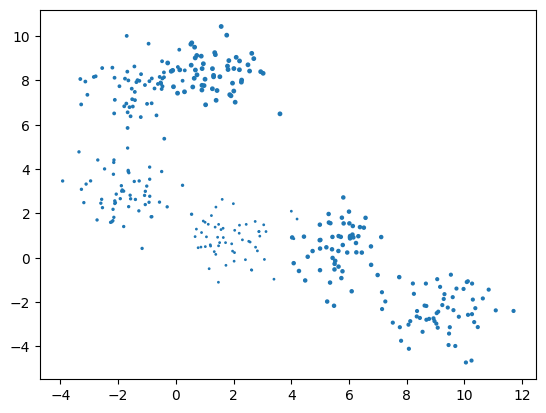

In [68]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], s=y_true)
plt.show()

**Opgave 2.2.**

Gebruik `KMeans` om een clustering te maken van de punten in array `X`. Kies voor `k` = 5.

In [69]:
model = KMeans(n_clusters=7)
model.fit(X)
y_kmeans = model.predict(X)


**Opgave 2.3.**

Bepaal de score van gevonden clustering.

In [74]:
from sklearn.metrics import silhouette_score

inertia = model.inertia_
print("Inertia: ", inertia)

silhouette = silhouette_score(X, y_kmeans)
print("Silhouette: ", silhouette)


Inertia:  776.5956682517461
Silhouette:  0.48196963985596963


**Opgave 2.4.**

Pas de scatterplot van opgave 2.1 aan en visualiseer de gevonden clusters.

**Opgave 2.5.**

Maak een clustering voor `k` = 1 t/m 20. Geef aan voor welke `k` de clustering het _beste_ is. Onderbouw wat je onder het _beste_ verstaat.

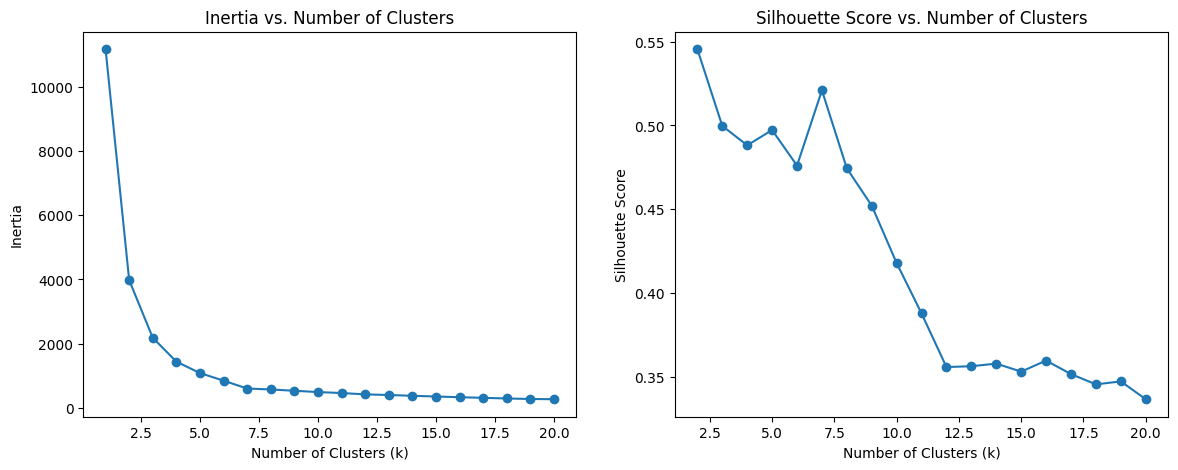

The best number of clusters (k) is: 2
The best clustering is determined based on the highest silhouette score, which measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assuming X is your data array
inertia = []
silhouette_scores = []

# Loop over k from 1 to 20
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    
    # Calculate inertia
    inertia.append(kmeans.inertia_)
    
    # Calculate silhouette score only if k > 1
    if k > 1:
        score = silhouette_score(X, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(np.nan)  # Placeholder for k=1

# Plot inertia and silhouette scores
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 21), inertia, marker='o')
plt.title('Inertia vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(range(2, 21), silhouette_scores[1:], marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Determine the best k based on silhouette score
best_k = np.argmax(silhouette_scores[1:]) + 2  # +2 because index 0 corresponds to k=2
print(f"The best number of clusters (k) is: {best_k}")

# Justification
print("The best clustering is determined based on the highest silhouette score, which measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.")

In [76]:
silhouette_scores


[nan,
 0.545480749246009,
 0.49970812833218803,
 0.48815873119201497,
 0.4972620557959448,
 0.4760458815515025,
 0.5209430891151505,
 0.47441445167464125,
 0.45213329666692575,
 0.4178939945699362,
 0.3878400679883393,
 0.3558491418324185,
 0.35635800302075105,
 0.3579041757517929,
 0.3531234561168742,
 0.3597364140214711,
 0.35165211626682596,
 0.34552367599664535,
 0.34730953224743943,
 0.33666558534949353]

**Opgave 2.6.**

Maak ook een clustering met `GaussianMixture` met de in opgave 2.5 gekozen `k`. 

**Opgave 2.7.**

Ga op zoek naar punten uit `X` die voor `KMeans` en `GaussianMixture` in verschillende clusters zijn ingedeeld. Kies één punt en verklaar waarom de clustering afwijkt. 

## Einde toets
Voer `Restart & Run All` uit onder `Kernel` en check of er geen errors zijn.